# 09. ¿Ayuda FinBERT a predecir la siguiente sesión?

**Autor: Marco Padilla Gómez. Issue #51.** Comparación retrospectiva exploratoria, no prueba de rentabilidad.

El cuaderno 07 explica el interior del modelo; el 08 estudia el sentimiento y sus límites. Este último paso pregunta si sustituir el sentimiento de Alpha Vantage por el de FinBERT mejora la clasificación bursátil. No descarga noticias, no ejecuta FinBERT y no entrena modelos: lee los informes conservados.

Se comparan tres algoritmos tabulares, no tres modelos de lenguaje. FinBERT permanece congelado. El [protocolo previo](../docs/finbert_prediccion_protocolo.md) fija las reglas antes de obtener estos resultados.

## 1. Procedencia y comprobaciones

La ejecución se fija por nombre: nunca se escoge automáticamente la última ni la de mayor AUC. Las huellas verifican los informes versionados; los modelos y paneles completos permanecen locales y no son necesarios para leer este cuaderno.

In [1]:
from pathlib import Path
import hashlib
import json
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.metrics import roc_auc_score
from IPython.display import Markdown, display

ROOT = Path.cwd().resolve()
if not (ROOT / 'src').is_dir():
    ROOT = ROOT.parent
RUN = ROOT / 'reports/experiments/finbert-predictive-full-20260928'
manifest = json.loads((RUN / 'manifest.json').read_text(encoding='utf-8'))
assert manifest['status'] == 'complete'
prefix = RUN.relative_to(ROOT).as_posix() + '/'
checked = 0
for name, expected in manifest['output_sha256'].items():
    if name.startswith(prefix):
        assert hashlib.sha256((ROOT / name).read_bytes()).hexdigest() == expected, name
        checked += 1
print(f'Informes verificados: {checked}')
print('Revisión de FinBERT:', manifest['inference']['revision'])
print('Commit del ejecutor:', manifest['git_commit'])
print('Entrenamiento desde:', manifest['config']['training_start'])
print('Evaluación desde:', manifest['config']['outer_start'])
plt.rcParams.update({'figure.dpi': 110, 'font.size': 10})

Informes verificados: 18
Revisión de FinBERT: 4556d13015211d73dccd3fdd39d39232506f3e43
Commit del ejecutor: eaee42f12b0c64b06d8e2b8004e02e4db4e32fe0
Entrenamiento desde: 2021-01-01
Evaluación desde: 2023-10-16


## 2. Qué cambia y qué se mantiene

**Base financiera:** nueve variables relativas de precios e indicadores, sin noticias. **Alpha completo:** noticias deduplicadas desde 2021. **Alpha emparejado:** solo noticias con mención explícita de la empresa y sin ficha dinámica reconocida. **FinBERT emparejado:** exactamente esas mismas noticias, cambiando exclusivamente puntuación y etiqueta.

El híbrido tiene 22 variables; el retardo añade dos variables de la sesión anterior, no noticias del futuro. Las medias y proporciones se agregan por empresa y cierre real del mercado. Los días sin noticias no se eliminan. Se conserva la relevancia del proveedor en la media ponderada: FinBERT no estima relevancia corporativa ni atribuye por sí solo un sentimiento distinto a cada empresa del texto.

In [2]:
display(pd.DataFrame([{'Variante': name, 'Número de variables': len(columns), 'Variables': ', '.join(columns)}
                      for name, columns in manifest['feature_sets'].items()]))
display(pd.Series(manifest['news_counts'], name='Recuento de noticias y textos'))
assert [len(manifest['feature_sets'][v]) for v in ['base', 'hybrid', 'lag_1']] == [9, 22, 24]

,Variante,Número de variables,Variables
0,base,9,"daily_return, RSI, volatility_20, distance_sma..."
1,hybrid,22,"daily_return, RSI, volatility_20, distance_sma..."
2,lag_1,24,"daily_return, RSI, volatility_20, distance_sma..."


aligned                   46014
post_2020_deduplicated    37524
matched                   15937
unique_scored_texts       14699
truncated_texts               0
dynamic_pages_flagged      1478
Name: Recuento de noticias y textos, dtype: int64

## 3. Cobertura y límites del filtrado

El volumen se cuenta por pareja noticia-empresa, por lo que un texto compartido puede contarse más de una vez. El filtro se fijó mediante alias, títulos y rutas de URL, no mediante retornos ni etiquetas de IA. Es imperfecto: ni una marca temporal ni la ausencia de una alerta certifican que el resumen actual existiese entonces.

En la tabla de cobertura heredada, `original` significa Alpha completo y `deduplicated` significa el subconjunto emparejado; ambos ya estaban deduplicados. No se deben comparar los modelos solo en los días con noticias.

Noticias  Sesiones con noticias  Sesiones  \
Enfoque        ticker Año                                               
Alpha completo AAPL   2021       867                    243       252   
                      2022       833                    237       251   
                      2023       610                    215       250   
                      2024       717                    235       252   
                      2025      3882                    241       248   
               MSFT   2021      1240                    249       252   
                      2022      1316                    248       251   
                      2023       988                    236       250   
                      2024      1265                    250       252   
                      2025      7833                    248       248   
               NVDA   2021       437                    191       252   
                      2022       563                    212       251   
                      2023       587                    209       250   
                      2024      1118                    247       252   
                      2025      9295                    245       248   
               TSLA   2021       735                    234       252   
                      2022       794                    237       251   
                      2023       456                    199       250   
                      2024       521                    222       252   
                      2025      3240                    236       248   
Emparejado     AAPL   2021       424                    198       252   
                      2022       355                    183       251   
                      2023       253                    147       250   
                      2024       286                    162       252   
                      2025      1972                    192       248   
               MSFT   2021       472                    211       252   
                      2022       488                    209       251   
                      2023       305                    157       250   
                      2024       416                    205       252   
                      2025      2947                    214       248   
               NVDA   2021       242                    131       252   
                      2022       278                    137       251   
                      2023       220                    128       250   
                      2024       514                    201       252   
                      2025      3979                    228       248   
               TSLA   2021       348                    182       252   
                      2022       359                    185       251   
                      2023       231                    140       250   
                      2024       190                    129       252   
                      2025      1565                    188       248   

                            Cobertura de sesiones  
Enfoque        ticker Año                          
Alpha completo AAPL   2021               0.964286  
                      2022               0.944223  
                      2023               0.860000  
                      2024               0.932540  
                      2025               0.971774  
               MSFT   2021               0.988095  
                      2022               0.988048  
                      2023               0.944000  
                      2024               0.992063  
                      2025               1.000000  
               NVDA   2021               0.757937  
                      2022               0.844622  
                      2023               0.836000  
                      2024               0.980159  
                      2025               0.987903  
               TSLA   2021               0.928571  
                      202

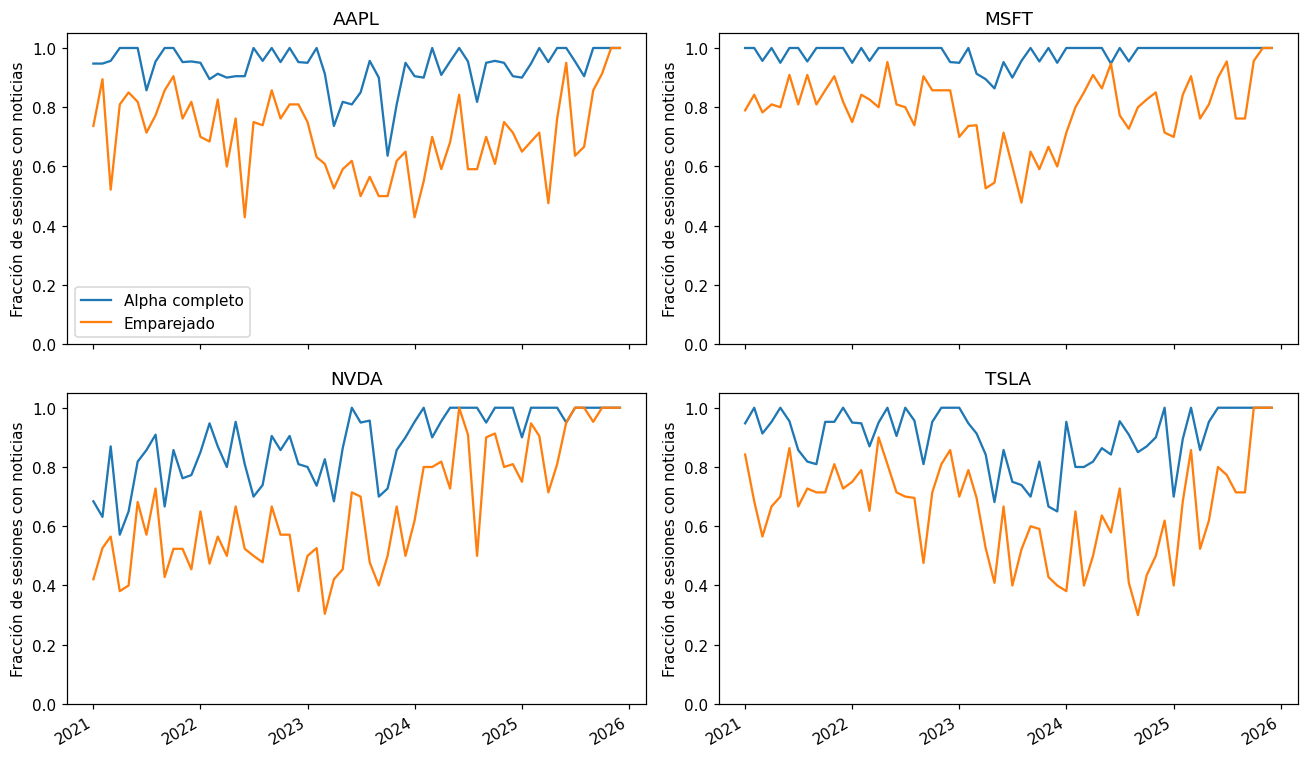

In [3]:
coverage = pd.read_csv(RUN / 'quality/coverage/monthly_coverage.csv')
coverage['Enfoque'] = coverage.approach.map({'original': 'Alpha completo', 'deduplicated': 'Emparejado'})
annual = coverage.assign(Año=coverage.month.str[:4]).groupby(['Enfoque', 'ticker', 'Año'])[['news', 'recorded_days', 'sessions']].sum()
annual['Cobertura de sesiones'] = annual.recorded_days / annual.sessions
annual = annual.rename(columns={'news': 'Noticias', 'recorded_days': 'Sesiones con noticias', 'sessions': 'Sesiones'})
display(annual)
fig, axes = plt.subplots(2, 2, figsize=(12, 7), sharex=True)
for ax, ticker in zip(axes.flat, ['AAPL', 'MSFT', 'NVDA', 'TSLA']):
    for name, part in coverage[coverage.ticker == ticker].groupby('Enfoque'):
        ax.plot(pd.to_datetime(part.month), part.recorded_day_ratio, label=name)
    ax.set_title(ticker)
    ax.set_ylim(0, 1.05)
    ax.set_ylabel('Fracción de sesiones con noticias')
axes[0, 0].legend()
fig.autofmt_xdate()
fig.tight_layout()
plt.show()

## 4. Del texto al sentimiento agregado

FinBERT tokeniza el titular y resumen, trunca a 512 tokens y obtiene tres probabilidades mediante BERT, el agrupador de `[CLS]` y una cabeza de clasificación. La puntuación es **P(positivo) − P(negativo)**. No es la probabilidad de subida del precio. Se usa FP32 y atención explícita, sin ajuste de pesos.

Las diferencias CPU/GPU se comprueban en 16 textos fijados por su hash. La coincidencia con Alpha Vantage mide acuerdo entre sistemas, no exactitud; no hay una nueva referencia humana.

,count,mean,std,min,25%,50%,75%,max
max_probability_error,16.0,3.764872e-07,5.001225e-07,5.587935e-09,5.355105e-08,2.160668e-07,5.513430e-07,0.000002


,Empresa,Noticias,Acuerdo de etiquetas,Correlación de Pearson,Correlación de Spearman
0,AAPL,3311,0.559650,0.559693,0.529003
1,MSFT,4641,0.592976,0.561595,0.482768
2,NVDA,5268,0.619590,0.451459,0.314290
3,TSLA,2717,0.560545,0.589605,0.586432


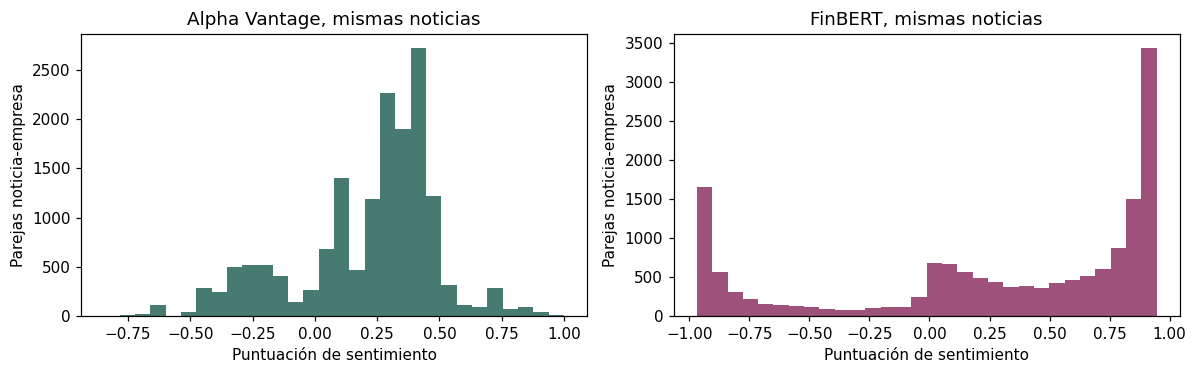

In [4]:
equivalence = pd.read_csv(RUN / 'sentiment/cpu_gpu_equivalence.csv')
assert equivalence.same_label.all()
assert equivalence.max_probability_error.max() <= 2e-5
display(equivalence.describe().T)
agreement = pd.read_csv(RUN / 'sentiment/provider_agreement.csv')
display(agreement.rename(columns={'ticker': 'Empresa', 'news': 'Noticias', 'label_agreement': 'Acuerdo de etiquetas',
                                  'pearson': 'Correlación de Pearson', 'spearman': 'Correlación de Spearman'}))
scores = pd.read_csv(RUN / 'sentiment/news_scores.csv')
assert not scores.news_id.duplicated().any()
assert scores[['negative', 'neutral', 'positive']].ge(0).all().all()
np.testing.assert_allclose(scores[['negative', 'neutral', 'positive']].sum(axis=1), 1, atol=1e-6)
np.testing.assert_allclose(scores.score, scores.positive - scores.negative, atol=1e-7)
assert (pd.to_datetime(scores.published_at, utc=True) <= pd.to_datetime(scores.market_close, utc=True)).all()
fig, axes = plt.subplots(1, 2, figsize=(11, 3.5))
axes[0].hist(scores.alpha_score, bins=30, color='#477b72')
axes[0].set_title('Alpha Vantage, mismas noticias')
axes[1].hist(scores.score, bins=30, color='#9e527a')
axes[1].set_title('FinBERT, mismas noticias')
for ax in axes:
    ax.set_xlabel('Puntuación de sentimiento')
    ax.set_ylabel('Parejas noticia-empresa')
fig.tight_layout()
plt.show()

## 5. Validación temporal y presupuesto

Cada bloque externo se predice usando solo el pasado. Dentro de ese pasado, tres bloques expansivos eligen entre dos configuraciones por algoritmo mediante AUC macro de empresas. Imputación y escalado se ajustan dentro de cada entrenamiento. Se purgan etiquetas cuyo horizonte llegue al comienzo de validación.

El conjunto de entrenamiento empieza en 2021 para no situar artificialmente el checkpoint publicado en 2020 en años anteriores. La misma restricción se aplica a la base. Son 63 ajustes externos, 378 internos y tres referencias mayoritarias. No se ha reabierto la búsqueda tras consultar la evaluación.

In [5]:
selected = pd.read_csv(RUN / 'tuning/selected_params.csv')
inner = pd.read_csv(RUN / 'tuning/inner_cv.csv')
assert len(selected) == 66 and len(inner) == 378
for table in [selected, inner]:
    assert (pd.to_datetime(table.train_target_end) < pd.to_datetime(table.valid_start)).all()
    assert (pd.to_datetime(table.train_start) >= pd.Timestamp('2021-01-01')).all()
    assert (pd.to_datetime(table.train_end) < pd.to_datetime(table.valid_start)).all()
display(selected[['outer_fold', 'train_start', 'train_end', 'train_target_end', 'train_rows', 'valid_start', 'valid_end', 'valid_rows']].drop_duplicates())
display(selected[['outer_fold', 'approach', 'dataset_type', 'model_name', 'features', 'inner_score', 'params']])

,outer_fold,train_start,train_end,train_target_end,train_rows,valid_start,valid_end,valid_rows
0,1,2021-01-04,2023-10-12,2023-10-13,2796,2023-10-16,2024-07-11,740
22,2,2021-01-04,2024-07-10,2024-07-11,3536,2024-07-12,2025-04-04,736
44,3,2021-01-04,2025-04-03,2025-04-04,4272,2025-04-07,2025-12-29,736


,outer_fold,approach,dataset_type,model_name,features,inner_score,params
0,1,financial,base,dummy,9,0.500000,{}
1,1,financial,base,logistic_regression,9,0.523367,"{""model__C"": 0.1}"
2,1,financial,base,random_forest,9,0.523791,"{""model__max_depth"": 8, ""model__min_samples_le..."
3,1,financial,base,hist_gradient_boosting,9,0.523935,"{""model__early_stopping"": false, ""model__max_i..."
4,1,alpha_all,hybrid,logistic_regression,22,0.530938,"{""model__C"": 0.1}"
...,...,...,...,...,...,...,...
61,3,finbert_matched,hybrid,random_forest,22,0.517750,"{""model__max_depth"": 8, ""model__min_samples_le..."
62,3,finbert_matched,hybrid,hist_gradient_boosting,22,0.519823,"{""model__early_stopping"": false, ""model__max_i..."
63,3,finbert_matched,lag_1,logistic_regression,24,0.511764,"{""model__C"": 0.1}"
64,3,finbert_matched,lag_1,random_forest,24,0.515224,"{""model__max_depth"": 4, ""model__min_samples_le..."


## 6. Métricas: todas las combinaciones

**AUC macro** es el promedio de los cuatro AUC calculados por empresa sobre las predicciones externas conservadas. 0,5 es la referencia de ausencia de ordenación discriminativa; no equivale a una exactitud del 50 %. La exactitud depende también del umbral 0,5 y del balance de clases. F1 macro aquí promedia las clases dentro de cada empresa y después las empresas.

No se ocultan algoritmos que empeoran. `mean_outer_auc` promedia los AUC de los tres bloques y no es igual al AUC calculado al juntar sus predicciones. La base solo se ajustó una vez por algoritmo y bloque.

In [6]:
predictions = pd.read_csv(RUN / 'predictions/all_predictions.csv', parse_dates=['Date'])
macro = pd.read_csv(RUN / 'metrics/macro_metrics.csv')
company = pd.read_csv(RUN / 'metrics/company_metrics.csv')
all_metrics = pd.read_csv(RUN / 'metrics/all_metrics.csv')
intervals = pd.read_csv(RUN / 'metrics/paired_intervals.csv')
keys = ['ticker', 'Date', 'target', 'outer_fold']
reference = None
for group, part in predictions.groupby(['approach', 'dataset_type', 'model_name']):
    ordered = part.sort_values(['ticker', 'Date']).reset_index(drop=True)
    assert not ordered.duplicated(['ticker', 'Date']).any()
    if reference is None:
        reference = ordered[keys]
    pd.testing.assert_frame_equal(reference, ordered[keys])
    per_company = [roc_auc_score(p.target, p.probability) for _, p in part.groupby('ticker')]
    row = macro[(macro.approach == group[0]) & (macro.dataset_type == group[1]) & (macro.model_name == group[2])]
    np.testing.assert_allclose(row.roc_auc.item(), np.mean(per_company), atol=1e-12)
print('Filas externas por combinación:', len(reference))
print('Sesiones externas:', reference.Date.nunique())
display(macro.round(4))

Filas externas por combinación: 2212
Sesiones externas: 553


,approach,dataset_type,model_name,roc_auc,mean_outer_auc,accuracy,balanced_accuracy,f1_macro,mcc
0,alpha_all,hybrid,hist_gradient_boosting,0.5189,0.5173,0.5158,0.5078,0.5003,0.0157
1,alpha_all,hybrid,logistic_regression,0.4896,0.4914,0.5163,0.5085,0.4942,0.0173
2,alpha_all,hybrid,random_forest,0.5105,0.5119,0.5122,0.5075,0.4998,0.0152
3,alpha_all,lag_1,hist_gradient_boosting,0.5153,0.5139,0.5158,0.5098,0.5042,0.0196
4,alpha_all,lag_1,logistic_regression,0.4903,0.4919,0.5140,0.5050,0.4914,0.0101
5,alpha_all,lag_1,random_forest,0.5174,0.5212,0.5158,0.5141,0.5066,0.0286
6,alpha_matched,hybrid,hist_gradient_boosting,0.5085,0.5104,0.5199,0.5118,0.5076,0.0248
7,alpha_matched,hybrid,logistic_regression,0.4875,0.4951,0.5176,0.5038,0.4827,0.0067
8,alpha_matched,hybrid,random_forest,0.5070,0.5107,0.5194,0.5079,0.4978,0.0146
9,alpha_matched,lag_1,hist_gradient_boosting,0.4917,0.4938,0.5014,0.4939,0.4902,-0.0120


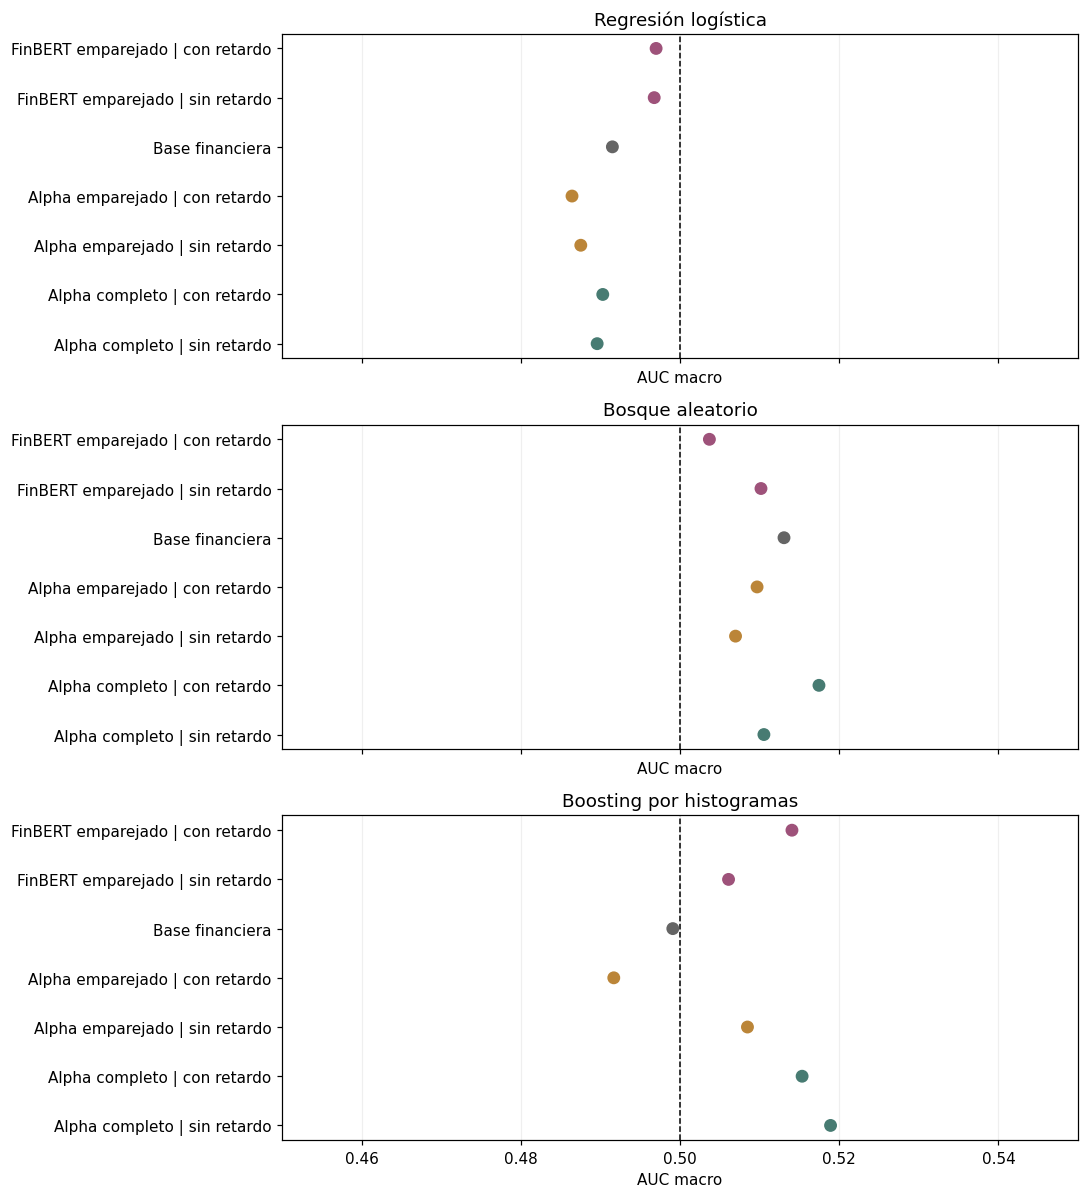

In [7]:
names = {'financial': 'Base financiera', 'alpha_all': 'Alpha completo', 'alpha_matched': 'Alpha emparejado',
         'finbert_matched': 'FinBERT emparejado'}
model_names = {'logistic_regression': 'Regresión logística', 'random_forest': 'Bosque aleatorio',
               'hist_gradient_boosting': 'Boosting por histogramas'}
variant_names = {'base': '', 'hybrid': ' | sin retardo', 'lag_1': ' | con retardo'}
macro['Etiqueta'] = macro.approach.map(names) + macro.dataset_type.map(variant_names)
fig, axes = plt.subplots(3, 1, figsize=(10, 11), sharex=True)
for ax, (model, title) in zip(axes, model_names.items()):
    part = macro[macro.model_name == model].sort_values(['approach', 'dataset_type'])
    colors = part.approach.map({'financial': '#656565', 'alpha_all': '#477b72', 'alpha_matched': '#bb8538', 'finbert_matched': '#9e527a'})
    ax.scatter(part.roc_auc, part.Etiqueta, color=colors, s=55, zorder=3)
    ax.grid(axis='x', alpha=.2)
    ax.axvline(.5, color='black', linestyle='--', linewidth=1)
    ax.set_xlim(min(.45, macro.roc_auc.min() - .01), max(.55, macro.roc_auc.max() + .01))
    ax.set_title(title)
    ax.set_xlabel('AUC macro')
fig.tight_layout()
plt.show()

## 7. Diferencias por empresa y bloque

Un promedio puede ocultar mejoras en una empresa y retrocesos en otra. El siguiente desglose conserva las cuatro empresas y los tres bloques, sin seleccionar únicamente el máximo. La estabilidad entre bloques importa más que un único número favorable.

In [8]:
for model, title in model_names.items():
    print(title)
    table = company[company.model_name == model].pivot(index=['approach', 'dataset_type'], columns='ticker', values='roc_auc')
    display(table.round(4))
outer = all_metrics[all_metrics.scope == 'outer_fold'].groupby(['approach', 'dataset_type', 'model_name', 'group']).roc_auc.mean().unstack('group')
display(outer.round(4))

Regresión logística


ticker                          AAPL    MSFT    NVDA    TSLA
approach        dataset_type                                
alpha_all       hybrid        0.4655  0.4696  0.5064  0.5168
                lag_1         0.4664  0.4746  0.5041  0.5161
alpha_matched   hybrid        0.4391  0.4728  0.5072  0.5310
                lag_1         0.4314  0.4813  0.5006  0.5324
financial       base          0.4399  0.4886  0.4959  0.5416
finbert_matched hybrid        0.4428  0.4894  0.5129  0.5419
                lag_1         0.4434  0.4955  0.5092  0.5399

Bosque aleatorio


ticker                          AAPL    MSFT    NVDA    TSLA
approach        dataset_type                                
alpha_all       hybrid        0.4799  0.4878  0.5500  0.5245
                lag_1         0.4852  0.5116  0.5636  0.5095
alpha_matched   hybrid        0.4869  0.4850  0.5300  0.5260
                lag_1         0.4835  0.5007  0.5266  0.5278
financial       base          0.5060  0.4937  0.5279  0.5247
finbert_matched hybrid        0.4873  0.4975  0.5299  0.5259
                lag_1         0.4631  0.4868  0.5342  0.5306

Boosting por histogramas


ticker                          AAPL    MSFT    NVDA    TSLA
approach        dataset_type                                
alpha_all       hybrid        0.5085  0.5091  0.5277  0.5303
                lag_1         0.4917  0.5070  0.5423  0.5203
alpha_matched   hybrid        0.5006  0.5139  0.5000  0.5194
                lag_1         0.4826  0.4894  0.4820  0.5126
financial       base          0.5162  0.4744  0.4766  0.5291
finbert_matched hybrid        0.5002  0.4752  0.5159  0.5331
                lag_1         0.5117  0.4768  0.5145  0.5532

group                                                   1.0     2.0     3.0
approach        dataset_type model_name                                    
alpha_all       hybrid       hist_gradient_boosting  0.5046  0.5102  0.5370
                             logistic_regression     0.5115  0.5001  0.4625
                             random_forest           0.5031  0.5054  0.5272
                lag_1        hist_gradient_boosting  0.5100  0.5041  0.5277
                             logistic_regression     0.5147  0.4970  0.4640
                             random_forest           0.5298  0.5071  0.5266
alpha_matched   hybrid       hist_gradient_boosting  0.5137  0.4934  0.5240
                             logistic_regression     0.5007  0.4934  0.4912
                             random_forest           0.4850  0.5074  0.5396
                lag_1        hist_gradient_boosting  0.4979  0.4781  0.5054
                             logistic_regression     0.4985  0.4986  0.4858
                             random_forest           0.4998  0.5078  0.5230
financial       base         dummy                   0.5000  0.5000  0.5000
                             hist_gradient_boosting  0.4999  0.5003  0.4961
                             logistic_regression     0.5141  0.4985  0.4817
                             random_forest           0.5048  0.5097  0.5214
finbert_matched hybrid       hist_gradient_boosting  0.4891  0.4979  0.5405
                             logistic_regression     0.5147  0.4858  0.4989
                             random_forest           0.5039  0.5014  0.5348
                lag_1        hist_gradient_boosting  0.5078  0.5188  0.5209
                             logistic_regression     0.5142  0.4921  0.4953
                             random_forest           0.4918  0.4983  0.5352

## 8. ¿Son claras las diferencias?

La comparación principal es FinBERT menos Alpha **sobre las mismas noticias**. También se conserva el efecto del filtro y el contraste con la base. Los intervalos remuestrean 1.000 veces bloques de 20 sesiones, usando las mismas fechas en las cuatro empresas y enfoques.

Un intervalo de diferencia que incluye cero no permite afirmar una mejora clara con este procedimiento. Los intervalos no incluyen el reentrenamiento ni corrigen las múltiples comparaciones; aunque excluyesen cero, el histórico ya inspeccionado seguiría siendo exploratorio.

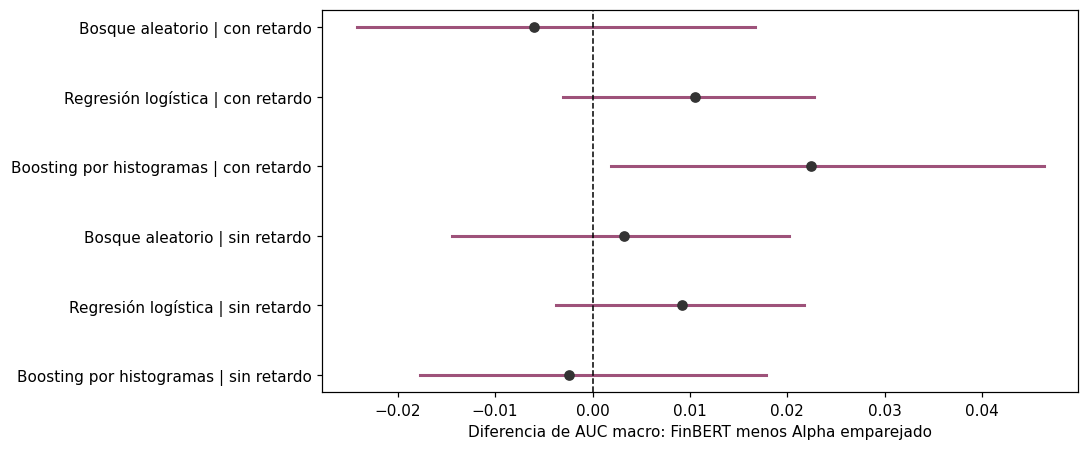

,approach,reference,dataset_type,model_name,roc_auc,reference_auc,auc_delta,delta_low,delta_high
4,finbert_matched,alpha_matched,hybrid,hist_gradient_boosting,0.5061,0.5085,-0.0024,-0.0177,0.0178
9,finbert_matched,alpha_matched,hybrid,logistic_regression,0.4967,0.4875,0.0092,-0.0037,0.0217
14,finbert_matched,alpha_matched,hybrid,random_forest,0.5102,0.5070,0.0032,-0.0144,0.0202
19,finbert_matched,alpha_matched,lag_1,hist_gradient_boosting,0.5141,0.4917,0.0224,0.0019,0.0463
24,finbert_matched,alpha_matched,lag_1,logistic_regression,0.4970,0.4864,0.0106,-0.0031,0.0228
29,finbert_matched,alpha_matched,lag_1,random_forest,0.5037,0.5097,-0.0060,-0.0242,0.0167
34,alpha_matched,alpha_all,hybrid,hist_gradient_boosting,0.5085,0.5189,-0.0104,-0.0397,0.0146
39,alpha_matched,alpha_all,hybrid,logistic_regression,0.4875,0.4896,-0.0021,-0.0280,0.0184
44,alpha_matched,alpha_all,hybrid,random_forest,0.5070,0.5105,-0.0036,-0.0277,0.0175
49,alpha_matched,alpha_all,lag_1,hist_gradient_boosting,0.4917,0.5153,-0.0237,-0.0493,0.0054


In [9]:
main = intervals[(intervals.ticker == 'macro') & (intervals.approach == 'finbert_matched') & (intervals.reference == 'alpha_matched')].copy()
main['Etiqueta'] = main.model_name.map(model_names) + main.dataset_type.map(variant_names)
fig, ax = plt.subplots(figsize=(10, 4.2))
for i, row in enumerate(main.itertuples()):
    ax.plot([row.delta_low, row.delta_high], [i, i], color='#9e527a', linewidth=2)
    ax.scatter(row.auc_delta, i, color='#333333', zorder=3)
ax.set_yticks(range(len(main)), main.Etiqueta)
ax.axvline(0, color='black', linestyle='--', linewidth=1)
ax.set_xlabel('Diferencia de AUC macro: FinBERT menos Alpha emparejado')
fig.tight_layout()
plt.show()
display(intervals[intervals.ticker == 'macro'][['approach', 'reference', 'dataset_type', 'model_name', 'roc_auc', 'reference_auc', 'auc_delta', 'delta_low', 'delta_high']].round(4))

## 9. Valoración y conclusión

La valoración escrita distingue mejora lingüística, cambio de cobertura y utilidad predictiva. Un desacuerdo entre FinBERT y Alpha no prueba que uno sea correcto; una mejora de AUC no demuestra rentabilidad. No se añaden más configuraciones ni se fusiona automáticamente esta rama.

In [10]:
display(Markdown((RUN / 'analysis.md').read_text(encoding='utf-8')))

# Utilidad predictiva de FinBERT

**Issue #51. Ejecución del 28/09/2026. Comparación exploratoria, sin fusión automática.**

## Conclusión

FinBERT cambia el sentimiento y mejora descriptivamente cuatro de las seis
variantes frente a Alpha Vantage sobre exactamente las mismas noticias. **No
demuestra una mejora general y robusta frente a utilizar solo datos financieros.**
El mejor AUC macro de FinBERT es 0,5141, con boosting y retardo. No es una
probabilidad de acierto del 51,41 % ni una estimación de rentabilidad.

El contraste favorable de boosting con retardo frente a Alpha emparejado tiene
un intervalo nominal positivo. Sin embargo, su propio intervalo de AUC incluye
0,5 y su diferencia frente a la base incluye cero. Además, hay seis contrastes
principales, treinta contrastes macro totales y fechas históricas ya consultadas.
No corresponde declarar un modelo ganador confirmado.

## Qué se ha comparado

Se conservan AAPL, MSFT, NVDA y TSLA; SPY no interviene. La base tiene 9 variables
financieras relativas, los híbridos 22 y el retardo 24. Se usan tres algoritmos:
regresión logística, bosque aleatorio y boosting por histogramas.

El [protocolo](../../../docs/finbert_prediccion_protocolo.md) quedó registrado
antes del cálculo financiero, en el commit `e5d8f6a`. El ejecutor corresponde a
`eaee42f`. Solo se permite elegir entre dos configuraciones por algoritmo, usando
AUC macro en tres bloques internos temporales. Se mantienen las tres particiones
externas, con purga, preprocesamiento dentro del entrenamiento y umbral 0,5.

Todos los enfoques entrenan desde enero de 2021, después de la publicación del
checkpoint. Por tanto, las bases se han vuelto a entrenar: **no debe compararse
esta tabla con las anteriores atribuyendo todo el cambio a FinBERT**. Hay 553
sesiones externas por empresa, del 16/10/2023 al 29/12/2025: 2.212 filas por
combinación. Se realizaron 63 ajustes externos, 378 internos y tres referencias
mayoritarias. La base se ajustó una vez por algoritmo y bloque; sus copias para
el remuestreo no se cuentan como modelos nuevos.

| Bloque | Entrenamiento hasta | Final máximo de etiqueta | Evaluación | Filas de entrenamiento / evaluación |
| --- | --- | --- | --- | ---: |
| 1 | 12/10/2023 | 13/10/2023 | 16/10/2023 a 11/07/2024 | 2.796 / 740 |
| 2 | 10/07/2024 | 11/07/2024 | 12/07/2024 a 04/04/2025 | 3.536 / 736 |
| 3 | 03/04/2025 | 04/04/2025 | 07/04/2025 a 29/12/2025 | 4.272 / 736 |

## Noticias y controles

De 46.014 parejas noticia-empresa alineadas al calendario quedan 37.524
deduplicadas desde 2021. El subconjunto emparejado contiene **15.937 parejas**,
el 42,47 % de ese total, y 14.699 textos únicos. El filtro exige alias explícito
de la empresa y excluye fichas dinámicas reconocibles por título o URL. No usa
resultados bursátiles ni las anotaciones de IA. Conserva la primera noticia por
titular normalizado y empresa dentro de 24 horas, sin deduplicar retrospectivamente.

Estos recuentos describen el corpus elegible alineado, no solo las sesiones con
objetivo disponible. En el panel financiero entran 15.844 parejas emparejadas y
37.297 del conjunto completo: las restantes no tienen una fila empresa-sesión
en el panel evaluable. Sus puntuaciones quedan trazadas, pero no añaden filas
ni intervienen en los clasificadores. La cobertura mensual cuenta únicamente
las que sí pertenecen al panel.

FinBERT procesa el campo original de titular y resumen, sin prefijos ni selección
de frases. Ninguno de los textos inferidos supera el límite de 512 tokens. Se usa
`ProsusAI/finbert`, revisión `4556d13015211d73dccd3fdd39d39232506f3e43`, congelado,
FP32, atención explícita y TF32 desactivado. La GPU y CPU coinciden en las 16
etiquetas prefijadas; el máximo error de probabilidad es 0,000001967.

La puntuación es P(positivo) − P(negativo). Las variables diarias se reconstruyen
por empresa y cierre, conservando sesiones sin noticias y la relevancia del
proveedor como peso. Un mismo texto compartido recibe la misma puntuación de
FinBERT: esto **no soluciona el sentimiento dirigido a cada empresa**.

| Empresa | Parejas emparejadas | Acuerdo de etiquetas con Alpha | Correlación de Pearson |
| --- | ---: | ---: | ---: |
| AAPL | 3.311 | 55,96 % | 0,5597 |
| MSFT | 4.641 | 59,30 % | 0,5616 |
| NVDA | 5.268 | 61,96 % | 0,4515 |
| TSLA | 2.717 | 56,05 % | 0,5896 |

Son acuerdos entre sistemas, no aciertos frente a una verdad humana. El filtro
es heurístico y los resúmenes pueden haberse actualizado después de su fecha
registrada; ni la purga ni excluir fichas reconocibles certifican una reconstrucción
histórica perfecta. El umbral de 2021 evita usar el checkpoint antes de publicarse,
pero no resuelve todas las incertidumbres de sus datos de preentrenamiento.

## AUC macro: todas las variantes

Media no ponderada del AUC de las cuatro empresas sobre las predicciones externas.
No debe confundirse con el AUC agrupando empresas ni con el promedio de bloques.

| Enfoque | Regresión logística | Bosque aleatorio | Boosting |
| --- | ---: | ---: | ---: |
| Base financiera | 0,4915 | 0,5131 | 0,4991 |
| Alpha completo, sin retardo | 0,4896 | 0,5105 | 0,5189 |
| Alpha completo, con retardo | 0,4903 | 0,5174 | 0,5153 |
| Alpha emparejado, sin retardo | 0,4875 | 0,5070 | 0,5085 |
| Alpha emparejado, con retardo | 0,4864 | 0,5097 | 0,4917 |
| FinBERT emparejado, sin retardo | 0,4967 | 0,5102 | 0,5061 |
| FinBERT emparejado, con retardo | 0,4970 | 0,5037 | 0,5141 |

El filtro reduce descriptivamente los seis AUC de Alpha, aunque sus intervalos
de diferencia incluyen cero. No basta con que las noticias parezcan más relevantes
para que el clasificador mejore: se pierde volumen y cambia la cobertura. Este
control evita atribuir a FinBERT el efecto conjunto del filtrado y el sentimiento.

## Diferencia sobre las mismas noticias

Intervalos pareados nominales del 95 %, con 1.000 remuestreos de bloques de 20
sesiones compartidos entre empresas. No incluyen reentrenamiento ni corrección
por comparaciones múltiples.

| Algoritmo | Variante | FinBERT menos Alpha | Intervalo de la diferencia |
| --- | --- | ---: | --- |
| Regresión logística | Sin retardo | +0,0092 | [−0,0037; +0,0217] |
| Bosque aleatorio | Sin retardo | +0,0032 | [−0,0144; +0,0202] |
| Boosting | Sin retardo | −0,0024 | [−0,0177; +0,0178] |
| Regresión logística | Con retardo | +0,0106 | [−0,0031; +0,0228] |
| Bosque aleatorio | Con retardo | −0,0060 | [−0,0242; +0,0167] |
| Boosting | Con retardo | +0,0224 | [+0,0019; +0,0463] |

Solo uno de los seis intervalos principales excluye cero. También es el único
de los treinta contrastes macro previstos. El boosting con FinBERT y retardo
tiene intervalo de AUC [0,4927; 0,5360]; frente a su base financiera, la diferencia
es +0,0150 con intervalo [−0,0044; +0,0369]. Ninguno de los seis contrastes
FinBERT-base excluye cero. La mejora respecto a Alpha emparejado no equivale a
superar claramente el azar, los precios solos o el Alpha completo.

## Exactitud y empresas

| FinBERT | Variante | Exactitud | Exactitud equilibrada | F1 macro | MCC |
| --- | --- | ---: | ---: | ---: | ---: |
| Regresión logística | Sin retardo | 51,49 % | 50,33 % | 0,4849 | 0,0030 |
| Bosque aleatorio | Sin retardo | 51,72 % | 50,76 % | 0,5002 | 0,0147 |
| Boosting | Sin retardo | 50,81 % | 49,98 % | 0,4938 | −0,0012 |
| Regresión logística | Con retardo | 50,59 % | 49,42 % | 0,4770 | −0,0154 |
| Bosque aleatorio | Con retardo | 51,72 % | 50,15 % | 0,4840 | 0,0026 |
| Boosting | Con retardo | 51,40 % | 50,71 % | 0,5033 | 0,0144 |

La referencia de clase mayoritaria alcanza 53,89 % de exactitud, AUC 0,5 y
exactitud equilibrada 50 %. Ningún modelo de esta ronda la supera en exactitud
con el umbral prefijado. Esto no convierte a la referencia en una estrategia
rentable, pero impide presentar un 51 % de aciertos como ventaja suficiente.

| FinBERT | Variante | AAPL | MSFT | NVDA | TSLA |
| --- | --- | ---: | ---: | ---: | ---: |
| Regresión logística | Sin retardo | 0,4428 | 0,4894 | 0,5129 | 0,5419 |
| Bosque aleatorio | Sin retardo | 0,4873 | 0,4975 | 0,5299 | 0,5259 |
| Boosting | Sin retardo | 0,5002 | 0,4752 | 0,5159 | 0,5331 |
| Regresión logística | Con retardo | 0,4434 | 0,4955 | 0,5092 | 0,5399 |
| Bosque aleatorio | Con retardo | 0,4631 | 0,4868 | 0,5342 | 0,5306 |
| Boosting | Con retardo | 0,5117 | 0,4768 | 0,5145 | 0,5532 |

El desglose muestra heterogeneidad, no una mejora universal: TSLA y NVDA son
descriptivamente más favorables que AAPL y MSFT. El valor 0,5532 de TSLA no se
elige como nuevo objetivo ni se usa para reabrir el ajuste. Los valores de todos
los enfoques, empresas y bloques están en `metrics/` y en el cuaderno 09.

## Qué aporta al TFG

La ampliación completa la conexión entre el funcionamiento interno de un modelo
de lenguaje, su comportamiento lingüístico y su utilidad en una tarea posterior.
No se limita a usar una API: se conserva el checkpoint, tokenización, representación,
probabilidades, huellas de textos, caché reanudable, metadatos numéricos, agregación
causal y comparación controlada. Se preservan resultados desfavorables y controles
que permiten separar el cambio de cobertura del cambio de sentimiento.

Una explicación plausible del escaso avance es la combinación de sentimiento
general no dirigido, resúmenes cortos, pérdida de cobertura y un objetivo diario
ruidoso. Son hipótesis, no mecanismos demostrados por esta tabla. Un modelo puede
comprender mejor una frase y no aportar una señal nueva sobre el retorno siguiente.

## Evidencias y reproducción

- `manifest.json`: versiones, código, parámetros, entradas y huellas de salidas.
- `sentiment/text_scores.csv`: una inferencia por texto exacto.
- `sentiment/news_scores.csv`: trazabilidad por noticia, empresa y cierre.
- `quality/news_eligibility.csv`: decisiones de filtrado y deduplicación.
- `metrics/`: resultados completos y 150 contrastes por empresa o promedio macro.
- `tuning/`: 66 selecciones externas y 378 filas de validación interna.
- `predictions/all_predictions.csv`: predicciones de las 22 combinaciones únicas.
- `verification.json`: comprobación de entradas, fuentes, modelos y probabilidades.
- `notebooks/09_finbert_predictive_evaluation.ipynb`: lectura explicada, figuras y recálculo de AUC.

Las 104 pruebas pasan tanto en el entorno CPU original como en el entorno separado
con PyTorch 2.8.0+cu128. Los modelos `.joblib`, pesos, caché SQLite y paneles locales
siguen excluidos de Git. No se modifican resultados anteriores ni `reports/final/`.
El tiempo de máquina no se contabiliza como dedicación personal en la memoria.

Para reproducir, instalar los requisitos generales y opcionales y disponer de
las entradas locales y los pesos fijados. Usar un identificador de ejecución nuevo:

```powershell
python -m src.experiments.run_finbert --run-dir reports/experiments/finbert-predictive-NUEVA --device cpu --cache data/experiments/finbert-cache-cpu/scores.sqlite
```

La ejecución registrada utiliza `--device cuda` en un entorno separado. La caché
rechaza metadatos incompatibles: no reutilizar una caché GPU como si fuese CPU.
Los pesos deben descargarse explícitamente mediante la guía del cuaderno 07.
La caché permite recuperar lotes de inferencia terminados; los ajustes financieros
se vuelven a ejecutar en un directorio nuevo si se interrumpe una ejecución.
